> Benjamin Nikholas

> Data Science / JCSDOL-014

> Modul 3 - Tugas 15

> 17 Juli 2024
---
---

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
df = pd.read_csv('Admission_Predict.csv')
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.2 KB


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Features: 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA' 

Target: 'Chance of Admit' 

In [40]:
X = df[['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA']]
y = df['Chance of Admit ']

In [41]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

Lakukan data splitting dengan proporsi 80:20 dan random_state = 42. 

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size = 0.8,
                                                    random_state = 42)

Gunakan model Ridge Regression dan Lasso Regression dengan berbagai nilai alpha (100000, 10000, 1000, 100, 10, 1, 0.1, 0.01, 0.001). 

In [43]:
alphas = [100000, 10000, 1000, 100, 10, 1, 0.1, 0.01, 0.001]
ridge_mse, lasso_mse = [], []

for alpha in alphas:
    
    # Ridge
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_train, y_train)
    
    ridge_y_pred_train = ridge.predict(X_train)
    ridge_y_pred_test = ridge.predict(X_test)
    
    # Lasso
    lasso = Lasso(alpha = alpha)
    lasso.fit(X_train, y_train)
    
    lasso_y_pred_train = lasso.predict(X_train)
    lasso_y_pred_test = lasso.predict(X_test)
    
    # Evaluation : MSE
    r_mse = mean_squared_error(y_test, ridge_y_pred_test).round(3)
    l_mse = mean_squared_error(y_test, lasso_y_pred_test).round(3)
    ridge_mse.append(r_mse)
    lasso_mse.append(l_mse)

Berapa nilai alpha terbaik untuk tiap model? 

Bandingkan performa kedua model ditinjau dari nilai MSE-nya, manakah yang lebih 
baik? 

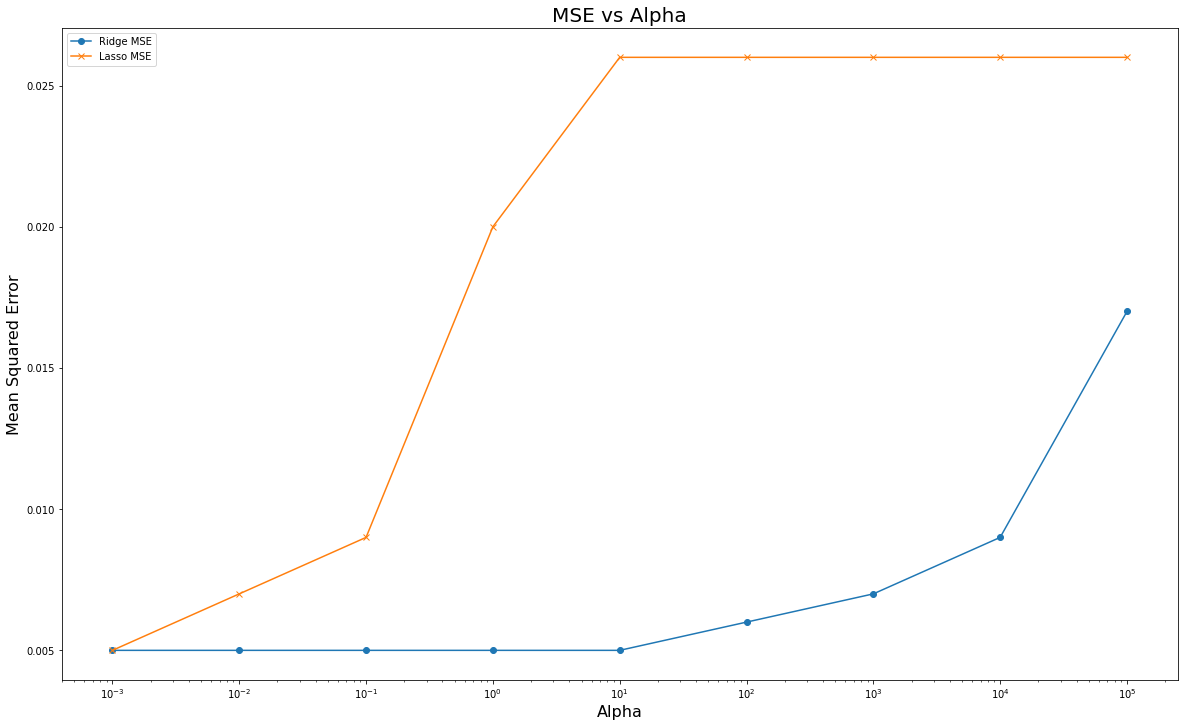

In [46]:
# MSE
plt.figure(figsize = (20, 12))
plt.plot(alphas, ridge_mse, 
         marker = 'o', label = 'Ridge MSE')
plt.plot(alphas, lasso_mse, marker = 'x', 
         label = 'Lasso MSE')
plt.xscale('log')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Mean Squared Error', fontsize = 16)
plt.title('MSE vs Alpha', fontsize = 20)
plt.legend()
plt.show()